# Exploratory Data Analysis - 4 Cities

Comparative EDA of Inside Airbnb data for **Porto**, **Lisbon**, **Madrid**, and **Barcelona**.

This notebook loads processed Parquet data via PySpark, computes statistics in Spark,
and converts to Pandas only for visualisation.

## 1. Setup & Data Loading

In [28]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
    "font.family": "DejaVu Sans",
    "figure.figsize": (14, 6),
})

def shorten_label(text, max_len=22):
    return text if len(text) <= max_len else text[:max_len-1] + "\u2026"

# Consistent colour palette for the 4 cities
CITY_COLORS = {
    'porto':     '#2196F3',
    'lisbon':    '#FF9800',
    'madrid':    '#E91E63',
    'barcelona': '#4CAF50',
}
CITY_ORDER = ['porto', 'lisbon', 'madrid', 'barcelona']
CITY_LABELS = {'porto': 'Porto', 'lisbon': 'Lisbon', 'madrid': 'Madrid', 'barcelona': 'Barcelona'}

In [29]:
spark = (
    SparkSession.builder
    .appName('EDA-4cities')
    .master('local[*]')
    .config('spark.driver.memory', '4g')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')
print('Spark version:', spark.version)

Spark version: 3.5.0


In [30]:
DATA_DIR = '../data/processed/'

listings  = spark.read.parquet(DATA_DIR + 'listings')
calendar  = spark.read.parquet(DATA_DIR + 'calendar')
reviews   = spark.read.parquet(DATA_DIR + 'reviews')
neighbourhoods = spark.read.parquet(DATA_DIR + 'neighbourhoods')

# Cache the most-used dataframes
listings.cache()
calendar.cache()
reviews.cache()

print('Datasets loaded successfully.')

Datasets loaded successfully.


In [31]:
# Schemas
for name, df in [('listings', listings), ('calendar', calendar),
                  ('reviews', reviews), ('neighbourhoods', neighbourhoods)]:
    print(f'\n--- {name} ---')
    df.printSchema()


--- listings ---
root
 |-- accommodates: string (nullable = true)
 |-- amenities: string (nullable = true)
 |-- availability_30: string (nullable = true)
 |-- availability_365: double (nullable = true)
 |-- availability_60: string (nullable = true)
 |-- availability_90: string (nullable = true)
 |-- availability_eoy: string (nullable = true)
 |-- bathrooms: string (nullable = true)
 |-- bathrooms_text: string (nullable = true)
 |-- bedrooms: string (nullable = true)
 |-- beds: string (nullable = true)
 |-- calculated_host_listings_count: double (nullable = true)
 |-- calculated_host_listings_count_entire_homes: string (nullable = true)
 |-- calculated_host_listings_count_private_rooms: string (nullable = true)
 |-- calculated_host_listings_count_shared_rooms: string (nullable = true)
 |-- calendar_last_scraped: string (nullable = true)
 |-- calendar_updated: string (nullable = true)
 |-- description: string (nullable = true)
 |-- estimated_occupancy_l365d: string (nullable = true)
 |-

In [32]:
# Row counts per city
for name, df in [('listings', listings), ('calendar', calendar),
                  ('reviews', reviews), ('neighbourhoods', neighbourhoods)]:
    print(f'\n--- {name} ---')
    df.groupBy('city').count().orderBy('city').show()


--- listings ---
+---------+-----+
|     city|count|
+---------+-----+
|barcelona|14913|
|   lisbon|21466|
|   madrid|20079|
|    porto|13189|
+---------+-----+


--- calendar ---
+---------+-------+
|     city|  count|
+---------+-------+
|barcelona|2303883|
|   lisbon|8979368|
|   madrid|9491474|
|    porto|5428676|
+---------+-------+


--- reviews ---
+---------+-------+
|     city|  count|
+---------+-------+
|barcelona| 973208|
|   lisbon|1687406|
|   madrid|1283042|
|    porto|1002693|
+---------+-------+


--- neighbourhoods ---
+---------+-----+
|     city|count|
+---------+-----+
|barcelona|   73|
|   lisbon|  134|
|   madrid|  128|
|    porto|  173|
+---------+-----+



## 2. Dataset Overview

In [33]:
# Summary table: rows and columns per dataset
summary_rows = []
for name, df in [('listings', listings), ('calendar', calendar),
                  ('reviews', reviews), ('neighbourhoods', neighbourhoods)]:
    summary_rows.append({'dataset': name, 'rows': df.count(), 'columns': len(df.columns)})

pd.DataFrame(summary_rows).set_index('dataset')

,rows,columns
dataset,,
listings,69647,84
calendar,26203401,10
reviews,4946349,9
neighbourhoods,508,3


In [34]:
# Breakdown by city
city_breakdown = []
for city in CITY_ORDER:
    city_breakdown.append({
        'city': CITY_LABELS[city],
        'listings': listings.filter(F.col('city') == city).count(),
        'calendar_rows': calendar.filter(F.col('city') == city).count(),
        'reviews': reviews.filter(F.col('city') == city).count(),
    })

pd.DataFrame(city_breakdown).set_index('city')

,listings,calendar_rows,reviews
city,,,
Porto,13189,5428676,1002693
Lisbon,21466,8979368,1687406
Madrid,20079,9491474,1283042
Barcelona,14913,2303883,973208


## 3. Listings Analysis

### 3.1 Price Distribution per City

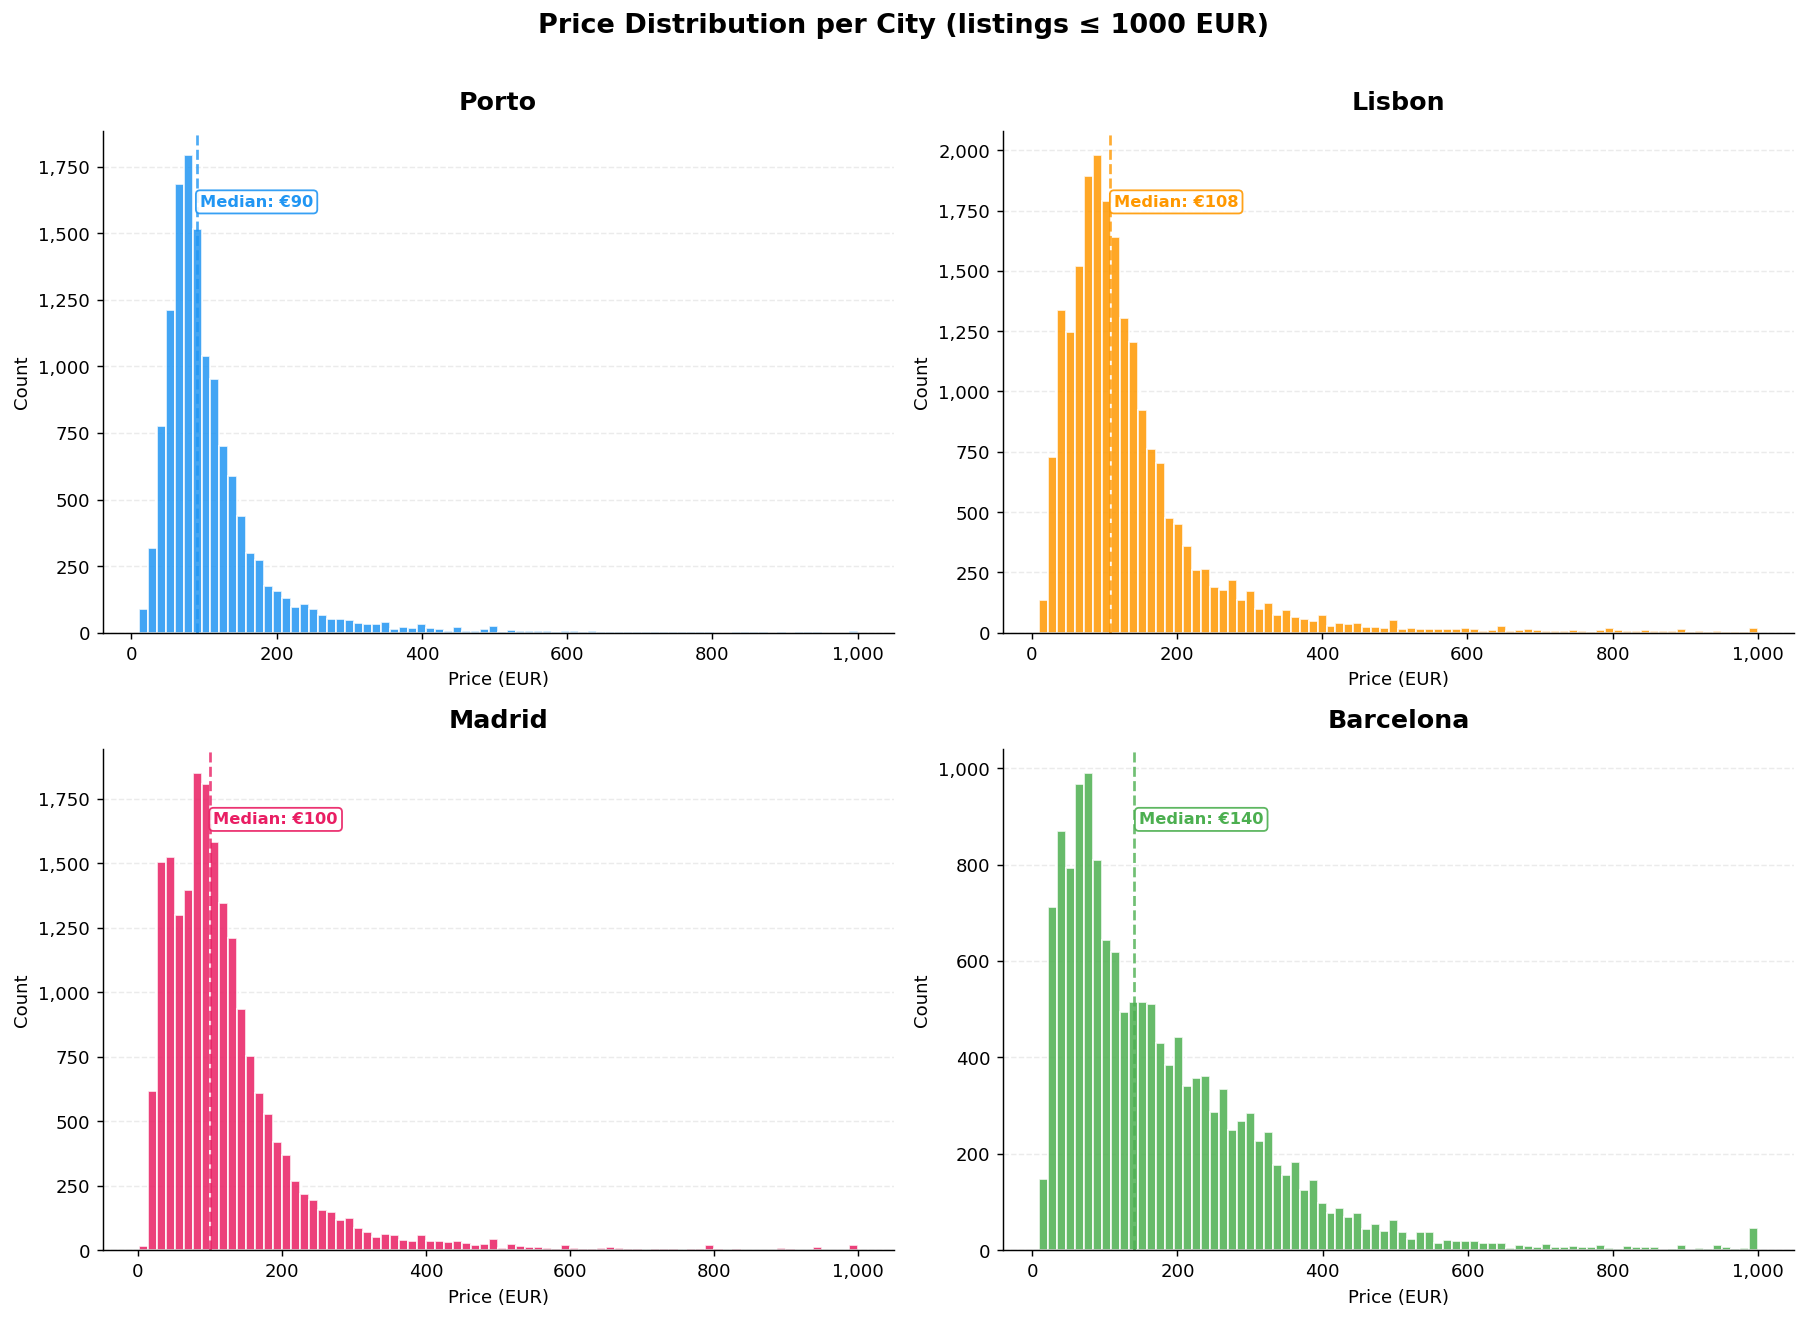

In [35]:
# Collect price data per city (filter outliers for visualisation: price <= 1000)
price_data = {}
for city in CITY_ORDER:
    pdf = (
        listings
        .filter((F.col('city') == city) & (F.col('price').isNotNull()) & (F.col('price') > 0) & (F.col('price') <= 1000))
        .select('price')
        .toPandas()
    )
    price_data[city] = pdf['price']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, city in zip(axes.flat, CITY_ORDER):
    color = CITY_COLORS[city]
    ax.hist(price_data[city], bins=80, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{CITY_LABELS[city]}', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Price (EUR)')
    ax.set_ylabel('Count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

    median_val = price_data[city].median()
    ax.axvline(median_val, color=color, linestyle="--", linewidth=1.5, alpha=0.8)
    ax.text(median_val * 1.05, ax.get_ylim()[1] * 0.85,
            f"Median: \u20ac{median_val:,.0f}",
            color=color, fontweight="bold", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor=color, alpha=0.9))

fig.suptitle('Price Distribution per City (listings \u2264 1000 EUR)', fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

### 3.2 Price Statistics per City

In [36]:
# Price statistics using Spark (percentile_approx for median)
price_stats = (
    listings
    .filter(F.col('price').isNotNull() & (F.col('price') > 0))
    .groupBy('city')
    .agg(
        F.count('price').alias('count'),
        F.round(F.mean('price'), 2).alias('mean'),
        F.round(F.percentile_approx('price', 0.5), 2).alias('median'),
        F.round(F.stddev('price'), 2).alias('std'),
        F.min('price').alias('min'),
        F.max('price').alias('max'),
        F.round(F.percentile_approx('price', 0.25), 2).alias('p25'),
        F.round(F.percentile_approx('price', 0.75), 2).alias('p75'),
        F.round(F.percentile_approx('price', 0.90), 2).alias('p90'),
        F.round(F.percentile_approx('price', 0.95), 2).alias('p95'),
    )
    .orderBy('city')
    .toPandas()
)
price_stats['city'] = price_stats['city'].map(CITY_LABELS)
price_stats.set_index('city')

,count,mean,median,std,min,max,p25,p75,p90,p95
city,,,,,,,,,,
Barcelona,14913,214.38,143.0,385.40,9.0,10000.0,74.0,256.0,379.0,500.0
Lisbon,21466,238.10,109.0,1485.01,10.0,40000.0,75.0,165.0,268.0,389.0
Madrid,20079,145.26,101.0,485.44,1.0,32000.0,64.0,150.0,227.0,311.0
Porto,13189,176.91,90.0,1149.68,10.0,40000.0,66.0,130.0,197.0,275.0


### 3.3 Room Type Distribution per City

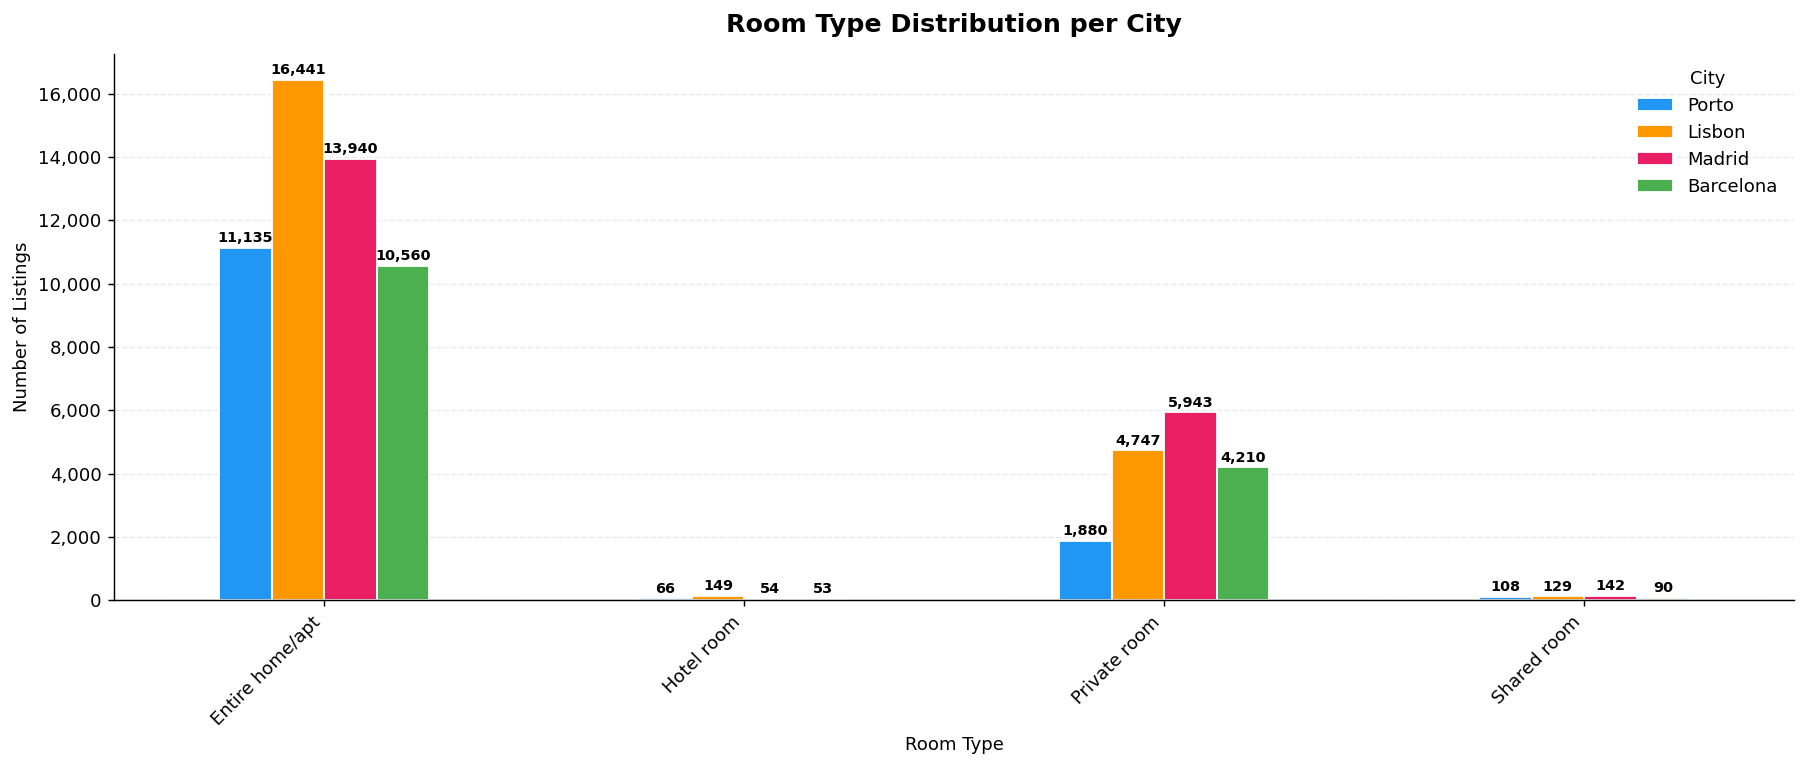

In [37]:
room_type_df = (
    listings
    .groupBy('city', 'room_type')
    .count()
    .orderBy('city', 'room_type')
    .toPandas()
)
room_type_df['city_label'] = room_type_df['city'].map(CITY_LABELS)

fig, ax = plt.subplots(figsize=(14, 6))
room_pivot = room_type_df.pivot(index='room_type', columns='city_label', values='count').fillna(0)
room_pivot = room_pivot[[CITY_LABELS[c] for c in CITY_ORDER]]
room_pivot.plot(kind='bar', ax=ax, color=[CITY_COLORS[c] for c in CITY_ORDER], edgecolor='white')
ax.set_title('Room Type Distribution per City', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Room Type')
ax.set_ylabel('Number of Listings')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title='City', frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Add value labels on every bar
for container in ax.containers:
    for bar in container:
        val = bar.get_height()
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + ax.get_ylim()[1] * 0.01,
                    f"{val:,.0f}", ha="center", fontweight="bold", fontsize=8)

plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()

### 3.4 Top 10 Neighbourhoods by Listing Count per City

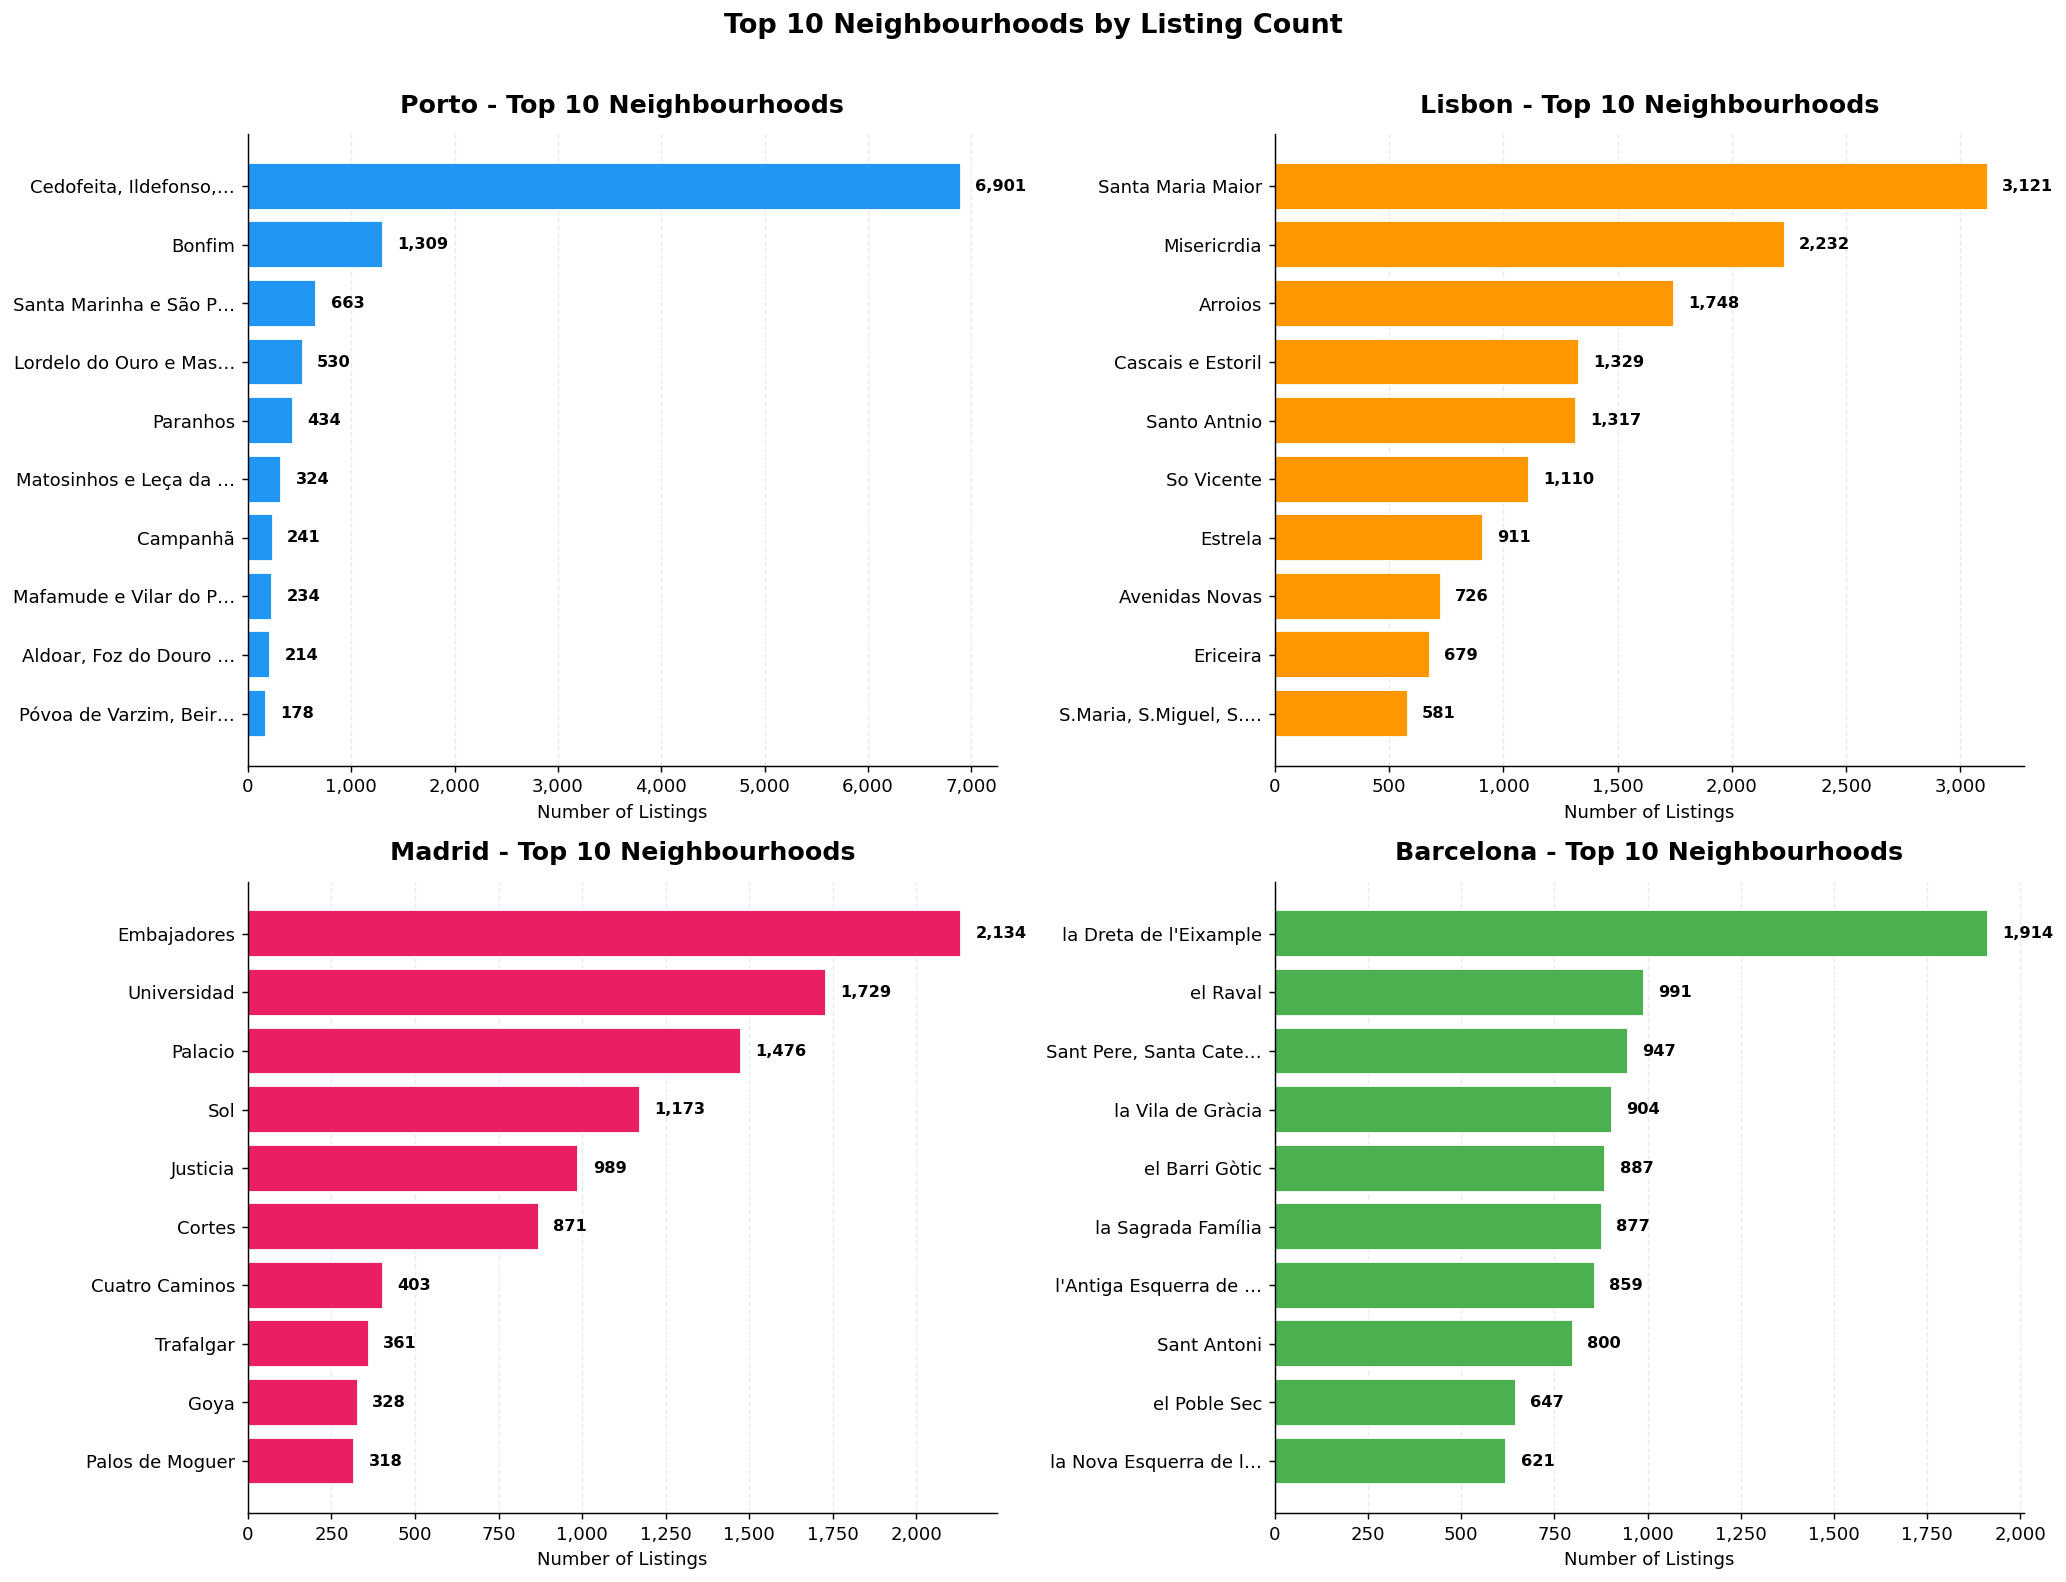

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, city in zip(axes.flat, CITY_ORDER):
    top_n = (
        listings
        .filter(F.col('city') == city)
        .groupBy('neighbourhood_cleansed')
        .count()
        .orderBy(F.desc('count'))
        .limit(10)
        .toPandas()
    )
    top_n = top_n.sort_values('count')
    labels = [shorten_label(n) for n in top_n['neighbourhood_cleansed']]
    bars = ax.barh(labels, top_n['count'], color=CITY_COLORS[city], edgecolor='white')
    ax.set_title(f'{CITY_LABELS[city]} - Top 10 Neighbourhoods', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Number of Listings')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

    # Add count labels outside bars
    max_val = top_n['count'].max()
    for bar, val in zip(bars, top_n['count']):
        ax.text(bar.get_width() + max_val * 0.02, bar.get_y() + bar.get_height() / 2,
                f"{val:,.0f}", va="center", fontweight="bold", fontsize=9)

fig.suptitle('Top 10 Neighbourhoods by Listing Count', fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

### 3.5 Accommodates Distribution per City

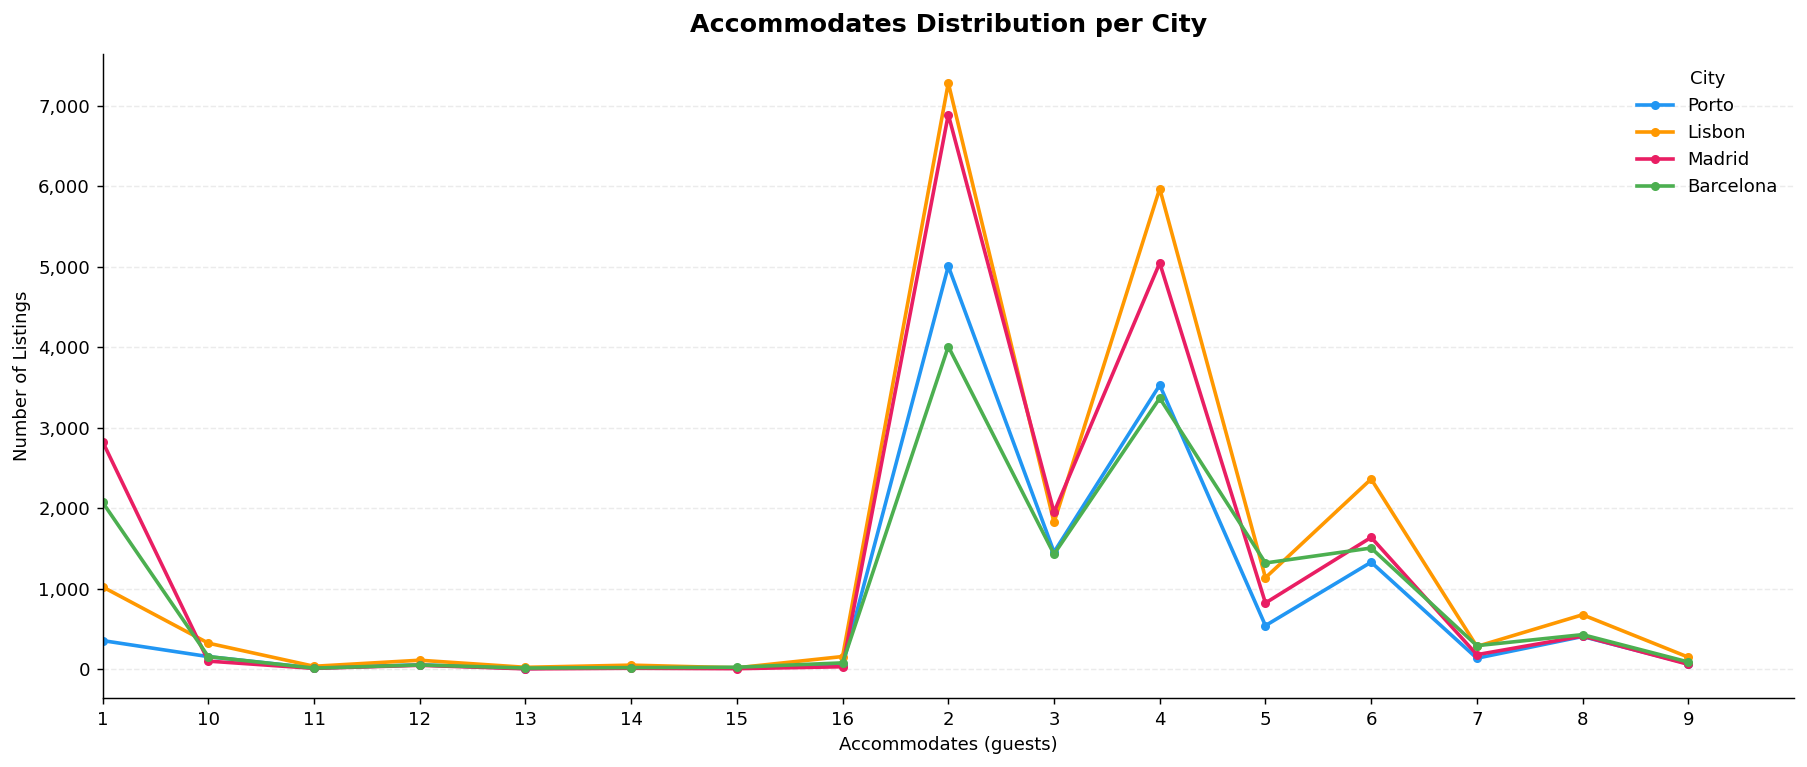

In [39]:
acc_df = (
    listings
    .filter(F.col('accommodates').isNotNull())
    .groupBy('city', 'accommodates')
    .count()
    .orderBy('city', 'accommodates')
    .toPandas()
)
acc_df['city_label'] = acc_df['city'].map(CITY_LABELS)

fig, ax = plt.subplots(figsize=(14, 6))
for city in CITY_ORDER:
    subset = acc_df[acc_df['city'] == city]
    ax.plot(subset['accommodates'], subset['count'], marker='o', label=CITY_LABELS[city],
            color=CITY_COLORS[city], linewidth=2, markersize=4)

ax.set_title('Accommodates Distribution per City', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Accommodates (guests)')
ax.set_ylabel('Number of Listings')
ax.set_xlim(0, 16)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title='City', frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

### 3.6 Price by Room Type per City (Boxplot, capped at 500 EUR)

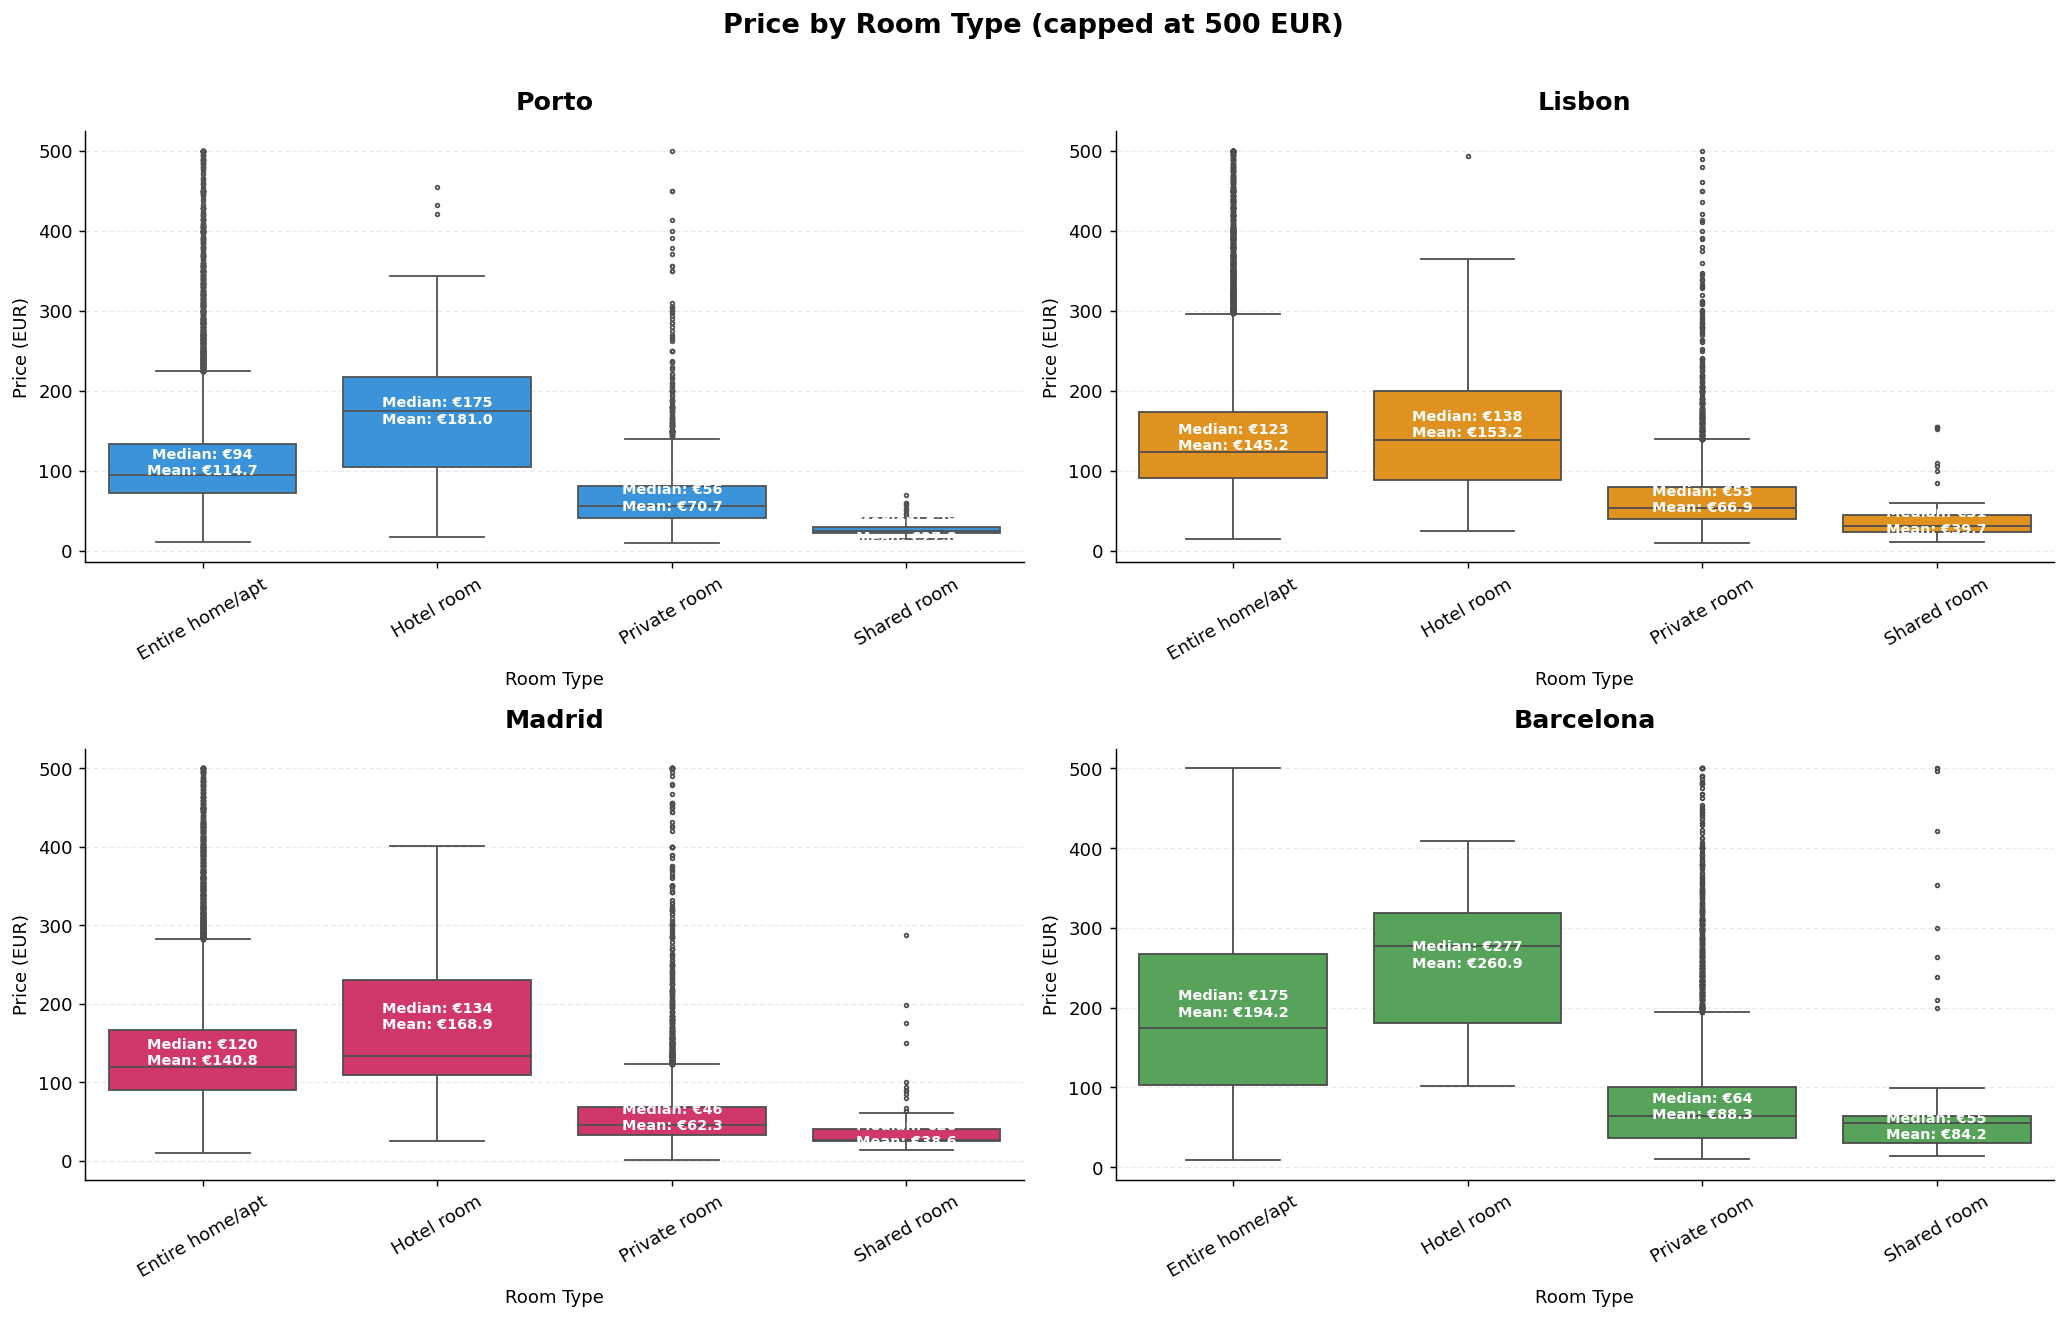

In [40]:
box_df = (
    listings
    .filter(
        (F.col('price').isNotNull()) &
        (F.col('price') > 0) &
        (F.col('price') <= 500) &
        (F.col('room_type').isNotNull())
    )
    .select('city', 'room_type', 'price')
    .toPandas()
)
box_df['city_label'] = box_df['city'].map(CITY_LABELS)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, city in zip(axes.flat, CITY_ORDER):
    subset = box_df[box_df['city'] == city]
    room_types = sorted(subset['room_type'].unique())
    sns.boxplot(data=subset, x='room_type', y='price', ax=ax,
                order=room_types, color=CITY_COLORS[city], fliersize=2)
    ax.set_title(f'{CITY_LABELS[city]}', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Room Type')
    ax.set_ylabel('Price (EUR)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

    # Add median and mean annotations inside each box
    for i, rt in enumerate(room_types):
        rt_data = subset[subset['room_type'] == rt]['price']
        if len(rt_data) == 0:
            continue
        med = rt_data.median()
        mn = rt_data.mean()
        q1 = rt_data.quantile(0.25)
        q3 = rt_data.quantile(0.75)
        ax.text(i, q1 + 0.62 * (q3 - q1),
                f"Median: \u20ac{med:.0f}\nMean: \u20ac{mn:.1f}",
                ha="center", va="center", fontsize=8, fontweight="bold", color="white")

fig.suptitle('Price by Room Type (capped at 500 EUR)', fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

## 4. Calendar Analysis

### 4.1 Monthly Availability Rate per City

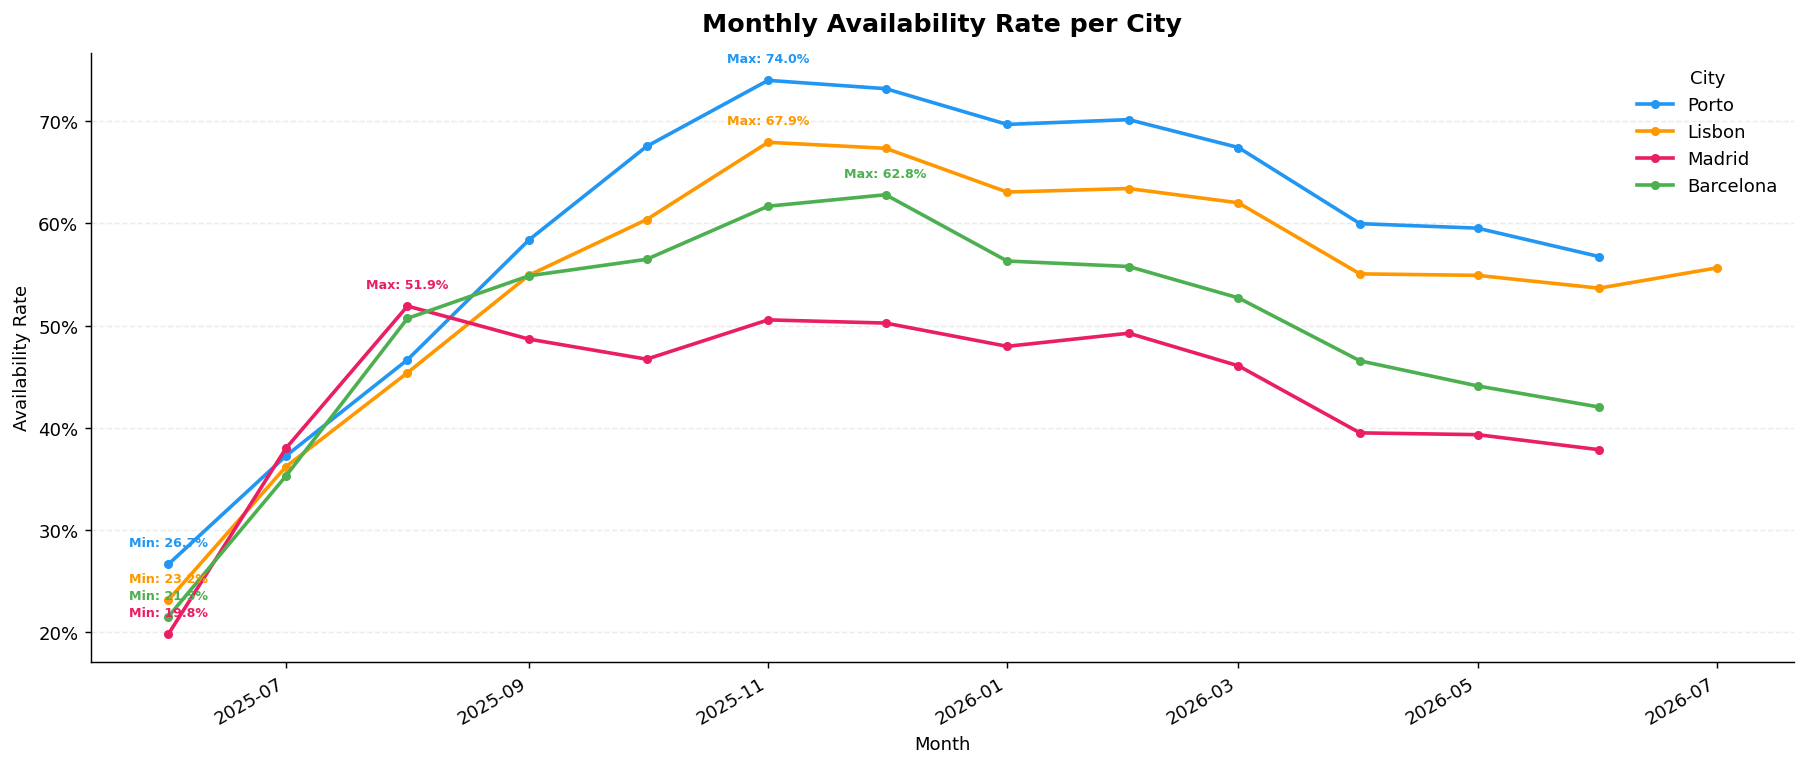

In [41]:
avail_df = (
    calendar
    .groupBy('city', 'year', 'month')
    .agg(
        F.count('available').alias('total'),
        F.sum(F.col('available').cast('int')).alias('available_count'),
    )
    .withColumn('availability_rate', F.col('available_count') / F.col('total'))
    .orderBy('city', 'year', 'month')
    .toPandas()
)
avail_df['date'] = pd.to_datetime(avail_df[['year', 'month']].assign(day=1))
avail_df['city_label'] = avail_df['city'].map(CITY_LABELS)

fig, ax = plt.subplots(figsize=(14, 6))
for city in CITY_ORDER:
    subset = avail_df[avail_df['city'] == city].sort_values('date')
    ax.plot(subset['date'], subset['availability_rate'], marker='o', markersize=4,
            label=CITY_LABELS[city], color=CITY_COLORS[city], linewidth=2)

    # Annotate min and max points
    idx_min = subset['availability_rate'].idxmin()
    idx_max = subset['availability_rate'].idxmax()
    for idx, label_prefix in [(idx_min, "Min"), (idx_max, "Max")]:
        row = subset.loc[idx]
        ax.annotate(f"{label_prefix}: {row['availability_rate']:.1%}",
                    xy=(row['date'], row['availability_rate']),
                    textcoords="offset points", xytext=(0, 10),
                    fontsize=7, fontweight="bold", color=CITY_COLORS[city],
                    ha="center")

ax.set_title('Monthly Availability Rate per City', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Availability Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(title='City', frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

### 4.2 Monthly Average Adjusted Price per City

In [42]:
# Check how much adjusted_price data exists per city
print("Adjusted price coverage per city:")
calendar.groupBy('city').agg(
    F.count('adjusted_price').alias('non_null'),
    F.count('*').alias('total'),
    F.round(F.count('adjusted_price') / F.count('*') * 100, 1).alias('pct_non_null')
).orderBy('city').show()

adj_price_df = (
    calendar
    .filter(F.col('adjusted_price').isNotNull() & (F.col('adjusted_price') > 0))
    .groupBy('city', 'year', 'month')
    .agg(F.round(F.mean('adjusted_price'), 2).alias('avg_adjusted_price'))
    .orderBy('city', 'year', 'month')
    .toPandas()
)

if adj_price_df.empty:
    print("\nNo adjusted_price data available in any city. Skipping chart.")
else:
    adj_price_df['date'] = pd.to_datetime(adj_price_df[['year', 'month']].assign(day=1))
    adj_price_df['city_label'] = adj_price_df['city'].map(CITY_LABELS)

    fig, ax = plt.subplots(figsize=(14, 6))
    plotted = False
    for city in CITY_ORDER:
        subset = adj_price_df[adj_price_df['city'] == city].dropna(subset=['avg_adjusted_price']).sort_values('date')
        if subset.empty:
            continue
        plotted = True
        ax.plot(subset['date'], subset['avg_adjusted_price'], marker='o', markersize=4,
                label=CITY_LABELS[city], color=CITY_COLORS[city], linewidth=2)

        # Annotate min and max points
        idx_min = subset['avg_adjusted_price'].idxmin()
        idx_max = subset['avg_adjusted_price'].idxmax()
        for idx, label_prefix in [(idx_min, "Min"), (idx_max, "Max")]:
            row = subset.loc[idx]
            ax.annotate(f"{label_prefix}: €{row['avg_adjusted_price']:,.0f}",
                        xy=(row['date'], row['avg_adjusted_price']),
                        textcoords="offset points", xytext=(0, 10),
                        fontsize=7, fontweight="bold", color=CITY_COLORS[city],
                        ha="center")

    ax.set_title('Monthly Average Adjusted Price per City', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Month')
    ax.set_ylabel('Average Adjusted Price (EUR)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{int(x):,}"))
    if plotted:
        ax.legend(title='City', frameon=False)
    else:
        ax.text(0.5, 0.5, 'No adjusted price data available', transform=ax.transAxes,
                ha='center', va='center', fontsize=14, color='grey')
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

Adjusted price coverage per city:
+---------+--------+-------+------------+
|     city|non_null|  total|pct_non_null|
+---------+--------+-------+------------+
|barcelona|       0|2303883|         0.0|
|   lisbon|       0|8979368|         0.0|
|   madrid|       0|9491474|         0.0|
|    porto|       0|5428676|         0.0|
+---------+--------+-------+------------+


No adjusted_price data available in any city. Skipping chart.


## 5. Reviews Analysis

### 5.1 Total Reviews per City

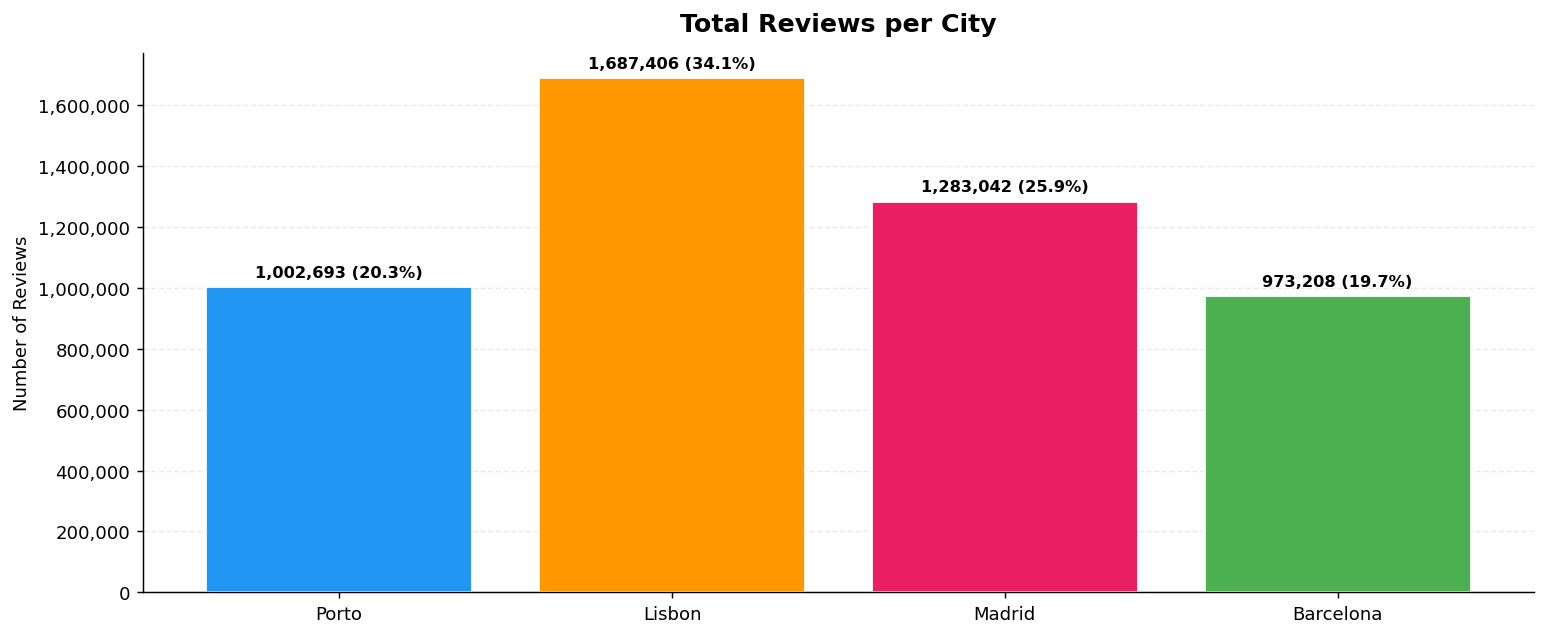

In [43]:
total_reviews = (
    reviews
    .groupBy('city')
    .count()
    .orderBy('city')
    .toPandas()
)
total_reviews['city_label'] = total_reviews['city'].map(CITY_LABELS)

fig, ax = plt.subplots(figsize=(12, 5))
values = [total_reviews[total_reviews['city'] == c]['count'].values[0] for c in CITY_ORDER]
bars = ax.bar(
    [CITY_LABELS[c] for c in CITY_ORDER],
    values,
    color=[CITY_COLORS[c] for c in CITY_ORDER],
    edgecolor='white'
)
max_val = max(values)
total_all = sum(values)
for bar in bars:
    val = int(bar.get_height())
    pct = val / total_all * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max_val * 0.02,
            f'{val:,} ({pct:.1f}%)', ha='center', fontweight='bold', fontsize=9)

ax.set_title('Total Reviews per City', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

### 5.2 Monthly Review Trend per City (from 2018)

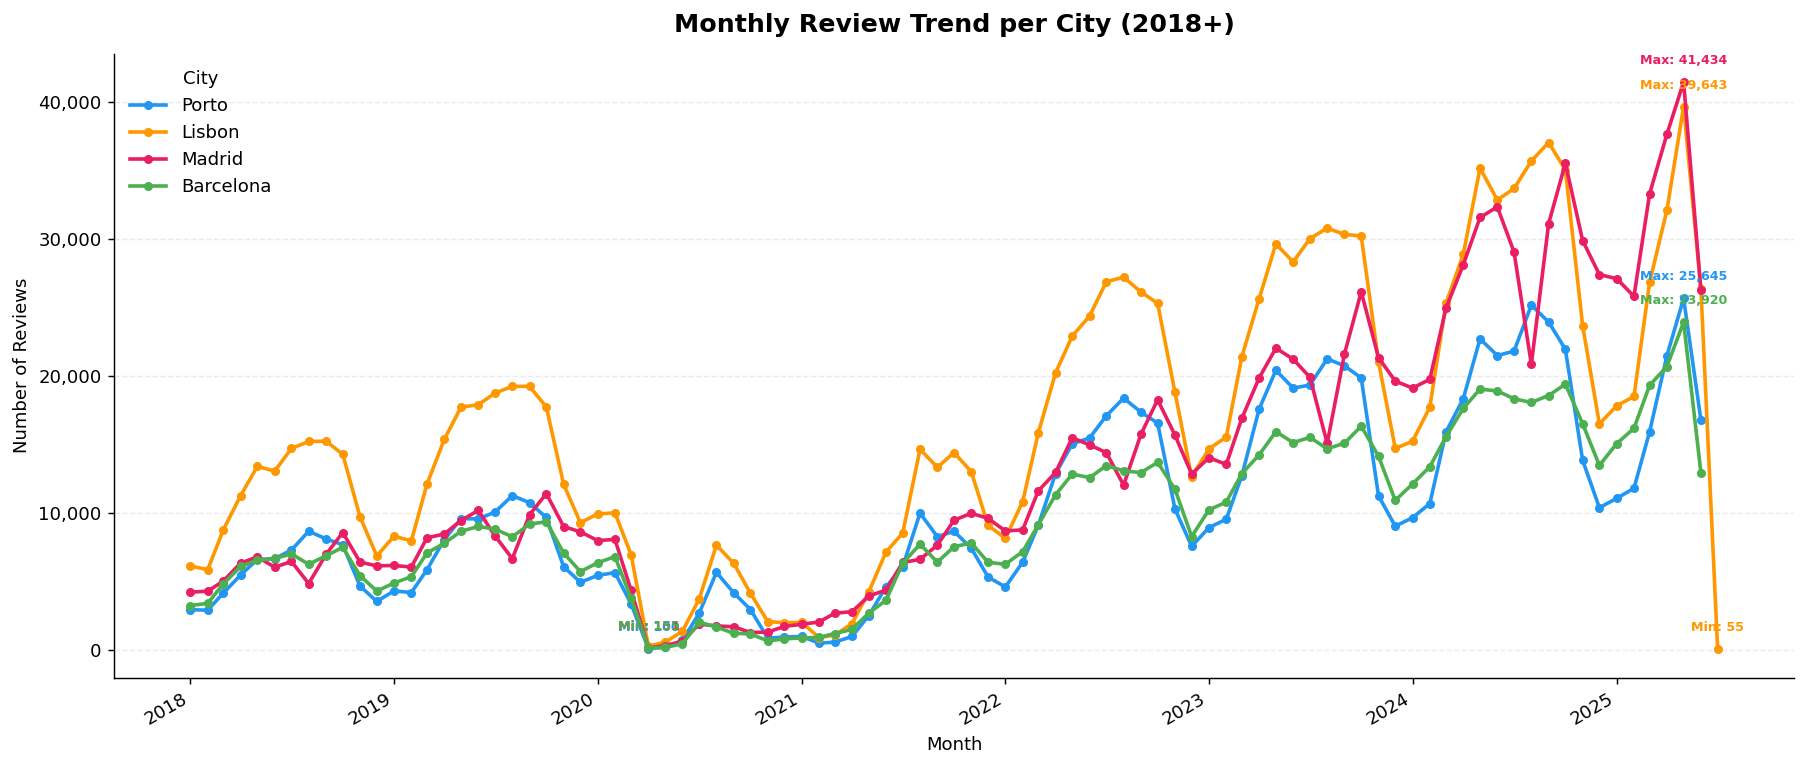

In [44]:
review_trend = (
    reviews
    .filter(F.col('year') >= 2018)
    .groupBy('city', 'year', 'month')
    .count()
    .orderBy('city', 'year', 'month')
    .toPandas()
)
review_trend['date'] = pd.to_datetime(review_trend[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 6))
for city in CITY_ORDER:
    subset = review_trend[review_trend['city'] == city].sort_values('date')
    ax.plot(subset['date'], subset['count'], label=CITY_LABELS[city],
            color=CITY_COLORS[city], linewidth=2, marker='o', markersize=4)

    # Annotate min and max
    idx_min = subset['count'].idxmin()
    idx_max = subset['count'].idxmax()
    for idx, label_prefix in [(idx_min, "Min"), (idx_max, "Max")]:
        row = subset.loc[idx]
        ax.annotate(f"{label_prefix}: {row['count']:,}",
                    xy=(row['date'], row['count']),
                    textcoords="offset points", xytext=(0, 10),
                    fontsize=7, fontweight="bold", color=CITY_COLORS[city],
                    ha="center")

ax.set_title('Monthly Review Trend per City (2018+)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title='City', frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

### 5.3 Year-over-Year Review Growth

In [45]:
yoy_reviews = (
    reviews
    .filter(F.col('year') >= 2018)
    .groupBy('city', 'year')
    .count()
    .orderBy('city', 'year')
    .toPandas()
)

# Calculate YoY growth per city
yoy_growth_rows = []
for city in CITY_ORDER:
    subset = yoy_reviews[yoy_reviews['city'] == city].sort_values('year')
    for i in range(1, len(subset)):
        prev = subset.iloc[i-1]['count']
        curr = subset.iloc[i]['count']
        growth = ((curr - prev) / prev * 100) if prev > 0 else 0
        yoy_growth_rows.append({
            'city': CITY_LABELS[city],
            'year': int(subset.iloc[i]['year']),
            'reviews': int(curr),
            'yoy_growth_pct': round(growth, 1)
        })

yoy_growth_df = pd.DataFrame(yoy_growth_rows)
yoy_pivot = yoy_growth_df.pivot(index='year', columns='city', values='yoy_growth_pct')
yoy_pivot = yoy_pivot[[CITY_LABELS[c] for c in CITY_ORDER]]
print('Year-over-Year Review Growth (%):')
yoy_pivot

Year-over-Year Review Growth (%):


city,Porto,Lisbon,Madrid,Barcelona
year,,,,
2019,37.3,30.6,42.0,33.9
2020,-65.3,-68.7,-69.6,-72.3
2021,70.9,64.3,116.5,109.5
2022,169.8,165.0,139.5,150.0
2023,25.9,22.2,43.3,25.2
2024,13.8,15.2,42.5,21.2
2025,-52.4,-52.1,-41.9,-46.2


## 6. Host Analysis

### 6.1 Single vs Multi-listing Hosts per City

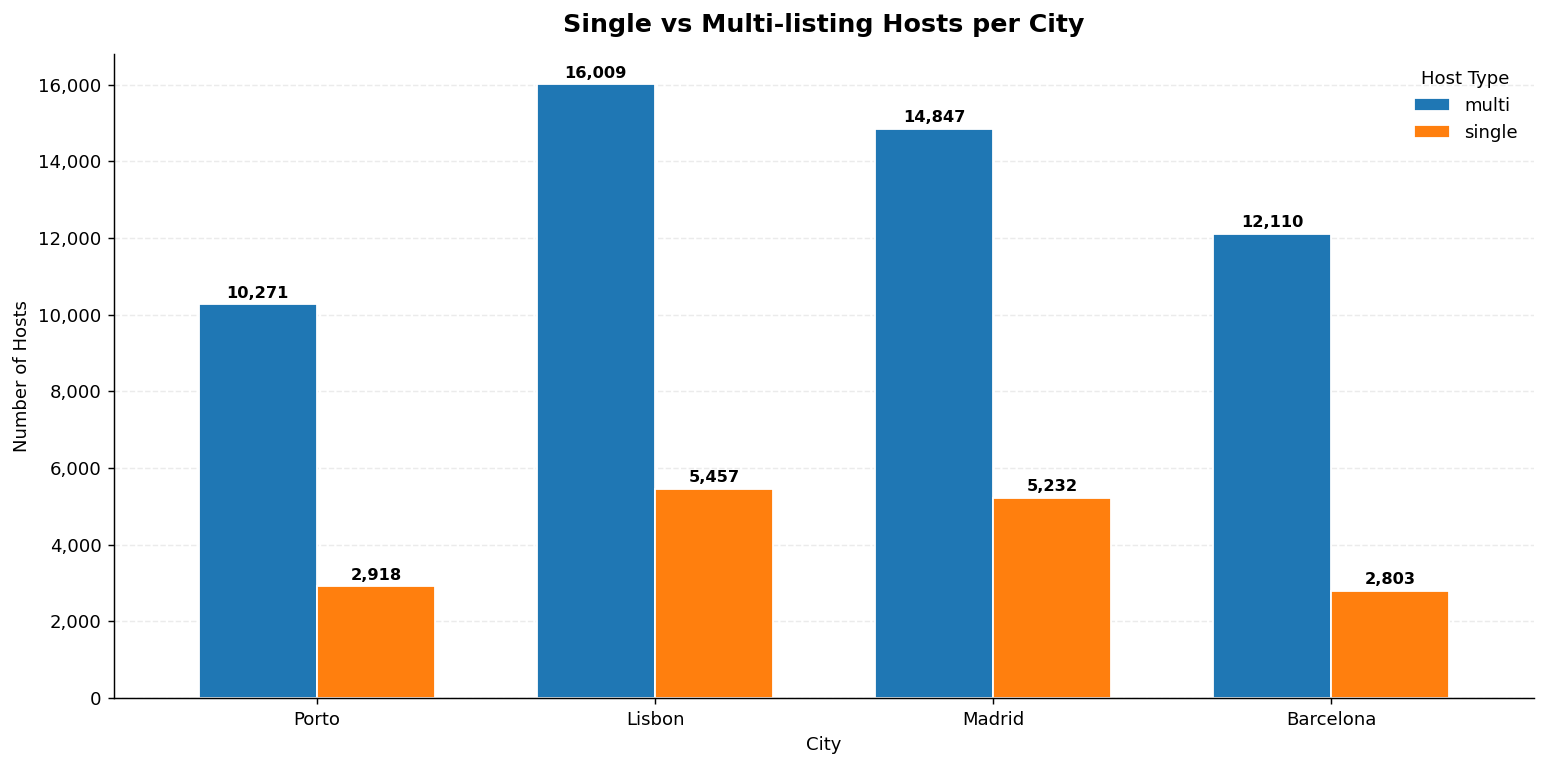

In [46]:
host_type_df = (
    listings
    .filter(F.col('host_type').isNotNull())
    .groupBy('city', 'host_type')
    .count()
    .orderBy('city', 'host_type')
    .toPandas()
)
host_type_df['city_label'] = host_type_df['city'].map(CITY_LABELS)

fig, ax = plt.subplots(figsize=(12, 6))
host_pivot = host_type_df.pivot(index='city_label', columns='host_type', values='count').fillna(0)
host_pivot = host_pivot.loc[[CITY_LABELS[c] for c in CITY_ORDER]]
host_pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.7)
ax.set_title('Single vs Multi-listing Hosts per City', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('City')
ax.set_ylabel('Number of Hosts')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title='Host Type', frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Add value labels on every bar
for container in ax.containers:
    for bar in container:
        val = bar.get_height()
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + ax.get_ylim()[1] * 0.01,
                    f"{val:,.0f}", ha="center", fontweight="bold", fontsize=9)

plt.xticks(rotation=0)
fig.tight_layout()
plt.show()

### 6.2 Host Concentration (Top 10% hosts control X% of listings)

In [47]:
# For each city, compute how many listings the top 10% of hosts control
host_concentration = []

for city in CITY_ORDER:
    # Count listings per host_id
    host_counts = (
        listings
        .filter(F.col('city') == city)
        .groupBy('host_id')
        .agg(F.count('id').alias('listing_count'))
        .orderBy(F.desc('listing_count'))
        .toPandas()
    )

    total_hosts = len(host_counts)
    total_listings_city = host_counts['listing_count'].sum()
    top_10_pct_n = max(1, int(np.ceil(total_hosts * 0.10)))
    top_10_listings = host_counts.head(top_10_pct_n)['listing_count'].sum()
    pct_controlled = round(top_10_listings / total_listings_city * 100, 1)

    host_concentration.append({
        'city': CITY_LABELS[city],
        'total_hosts': total_hosts,
        'top_10pct_hosts': top_10_pct_n,
        'listings_by_top_10pct': int(top_10_listings),
        'pct_of_total_listings': pct_controlled,
    })

conc_df = pd.DataFrame(host_concentration).set_index('city')
conc_df

,total_hosts,top_10pct_hosts,listings_by_top_10pct,pct_of_total_listings
city,,,,
Porto,4776,478,6516,49.4
Lisbon,8503,851,10514,49.0
Madrid,7800,780,10870,54.1
Barcelona,4535,454,8845,59.3


## 7. Geographic Distribution

### 7.1 Listings by Neighbourhood Group per City

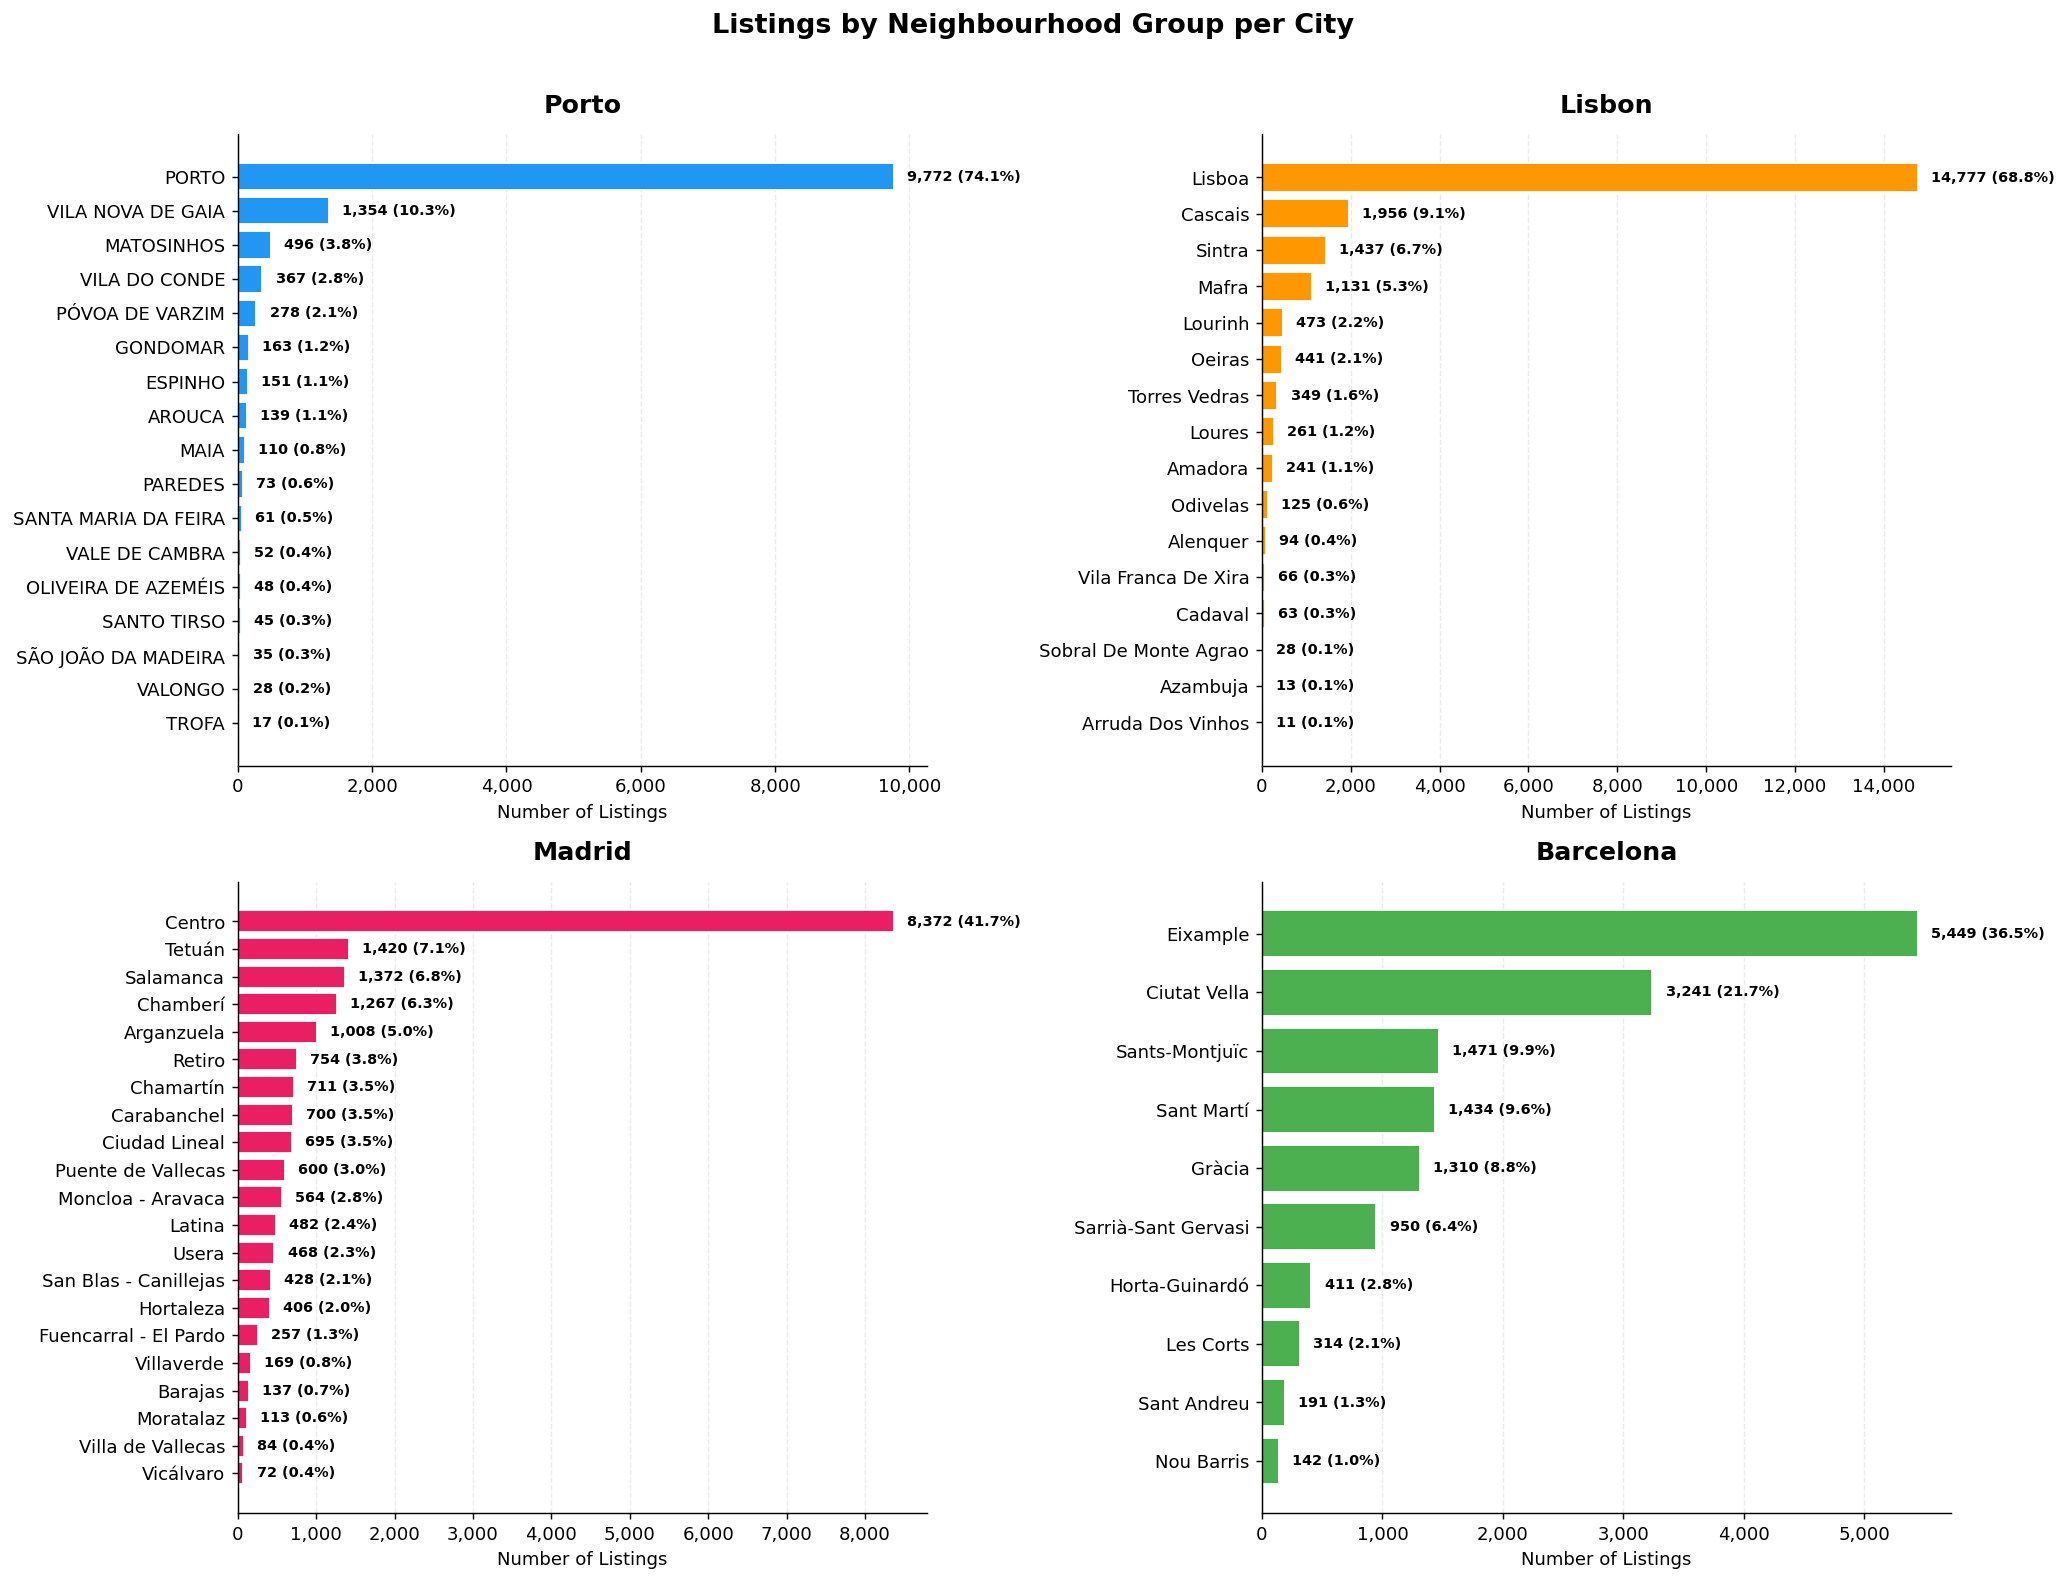

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, city in zip(axes.flat, CITY_ORDER):
    ng_df = (
        listings
        .filter(
            (F.col('city') == city) &
            F.col('neighbourhood_group_cleansed').isNotNull() &
            (F.col('neighbourhood_group_cleansed') != '')
        )
        .groupBy('neighbourhood_group_cleansed')
        .count()
        .orderBy(F.desc('count'))
        .toPandas()
    )

    if ng_df.empty:
        # Some cities may not have neighbourhood_group_cleansed; fall back to neighbourhood_cleansed
        ng_df = (
            listings
            .filter(F.col('city') == city)
            .groupBy('neighbourhood_cleansed')
            .count()
            .orderBy(F.desc('count'))
            .limit(15)
            .toPandas()
        )
        col_name = 'neighbourhood_cleansed'
        ax.set_title(f'{CITY_LABELS[city]} (by neighbourhood)', fontsize=14, fontweight='bold', pad=12)
    else:
        col_name = 'neighbourhood_group_cleansed'
        ax.set_title(f'{CITY_LABELS[city]}', fontsize=14, fontweight='bold', pad=12)

    ng_df = ng_df.sort_values('count')
    labels = [shorten_label(n) for n in ng_df[col_name]]
    bars = ax.barh(labels, ng_df['count'], color=CITY_COLORS[city], edgecolor='white')
    ax.set_xlabel('Number of Listings')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

    # Add count labels outside bars
    max_val = ng_df['count'].max()
    total_city = ng_df['count'].sum()
    for bar, val in zip(bars, ng_df['count']):
        pct = val / total_city * 100
        ax.text(bar.get_width() + max_val * 0.02, bar.get_y() + bar.get_height() / 2,
                f"{val:,.0f} ({pct:.1f}%)", va="center", fontweight="bold", fontsize=8)

fig.suptitle('Listings by Neighbourhood Group per City', fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

## 8. Cross-city Comparison Summary

In [49]:
# Build a final summary table with key metrics across all 4 cities
summary_data = []

for city in CITY_ORDER:
    city_listings = listings.filter(F.col('city') == city)
    city_cal = calendar.filter(F.col('city') == city)
    city_rev = reviews.filter(F.col('city') == city)

    stats = city_listings.filter(F.col('price').isNotNull() & (F.col('price') > 0)).agg(
        F.count('id').alias('n_listings'),
        F.round(F.mean('price'), 0).alias('avg_price'),
        F.round(F.percentile_approx('price', 0.5), 0).alias('median_price'),
        F.round(F.mean('number_of_reviews'), 1).alias('avg_reviews_per_listing'),
        F.round(F.mean('review_scores_rating'), 2).alias('avg_rating'),
        F.round(F.mean('availability_365'), 0).alias('avg_availability_365'),
    ).collect()[0]

    # Dominant room type
    dominant_rt = (
        city_listings
        .groupBy('room_type').count()
        .orderBy(F.desc('count'))
        .first()
    )

    # Total reviews
    total_rev = city_rev.count()

    # Availability rate from calendar
    avail_stats = city_cal.agg(
        F.round(F.mean(F.col('available').cast('int')) * 100, 1).alias('avg_availability_rate')
    ).collect()[0]

    summary_data.append({
        'City': CITY_LABELS[city],
        'Listings': int(stats['n_listings']),
        'Avg Price (EUR)': float(stats['avg_price']),
        'Median Price (EUR)': float(stats['median_price']),
        'Avg Rating': float(stats['avg_rating']) if stats['avg_rating'] else None,
        'Avg Reviews/Listing': float(stats['avg_reviews_per_listing']),
        'Total Reviews': total_rev,
        'Dominant Room Type': dominant_rt['room_type'] if dominant_rt else 'N/A',
        'Avg Availability (days/year)': float(stats['avg_availability_365']) if stats['avg_availability_365'] else None,
        'Calendar Availability Rate (%)': float(avail_stats['avg_availability_rate']),
    })

summary_table = pd.DataFrame(summary_data).set_index('City')
summary_table

,Listings,Avg Price (EUR),Median Price (EUR),Avg Rating,Avg Reviews/Listing,Total Reviews,Dominant Room Type,Avg Availability (days/year),Calendar Availability Rate (%)
City,,,,,,,,,
Porto,13189,177.0,90.0,4.72,72.0,1002693,Entire home/apt,246.0,61.3
Lisbon,21466,238.0,109.0,4.67,73.8,1687406,Entire home/apt,226.0,56.8
Madrid,20079,145.0,101.0,4.64,57.2,1283042,Entire home/apt,203.0,45.3
Barcelona,14913,214.0,143.0,4.62,60.2,973208,Entire home/apt,222.0,51.2


### Key Findings

The cells above produce the cross-city comparison table dynamically. After running the notebook,
review the outputs and note the following patterns:

- **Market size**: Compare the number of listings across cities to understand relative market scale.
- **Pricing**: Differences in median price reveal positioning -- lower medians may indicate more budget-oriented markets.
- **Room types**: The dominant room type (typically "Entire home/apt") and its share varies across cities.
- **Seasonality**: The calendar availability and adjusted-price trends show seasonal demand peaks.
- **Reviews as demand proxy**: Monthly review trends reveal COVID-19 impact and subsequent recovery patterns.
- **Host concentration**: The share of listings controlled by the top 10% of hosts highlights professionalisation levels.
- **Geographic concentration**: Certain neighbourhood groups dominate the supply in each city.

In [50]:
# Clean up
spark.stop()
print('Spark session stopped.')

Spark session stopped.
